In [1]:
def plot_mfcc(m, fs_new, hop_samples, ax=None, normalise=False):
    """Plot an (n_coeffs, n_frames) MFCC matrix against real time."""
    img_data = m
    if normalise:  # display only: stops one large-magnitude row from washing out the rest
        img_data = (m - m.mean(axis=1, keepdims=True)) / (m.std(axis=1, keepdims=True) + 1e-9)

    n_coeffs, n_frames = m.shape
    t = np.arange(n_frames) * (hop_samples / fs_new)
    coeff_idx = np.arange(n_coeffs)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    img = ax.pcolormesh(t, coeff_idx, img_data, shading="auto")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MFCC coefficient")

    if standalone:
        ax.set_title("MFCC")
        plt.colorbar(img, ax=ax, label="Coefficient value")

    return img

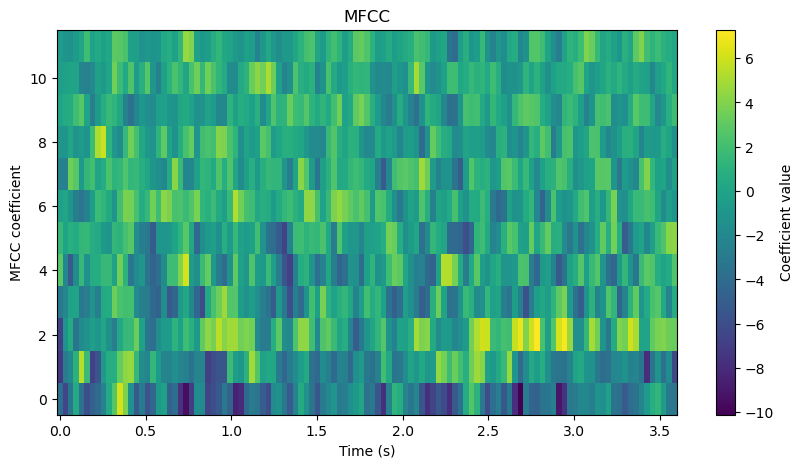

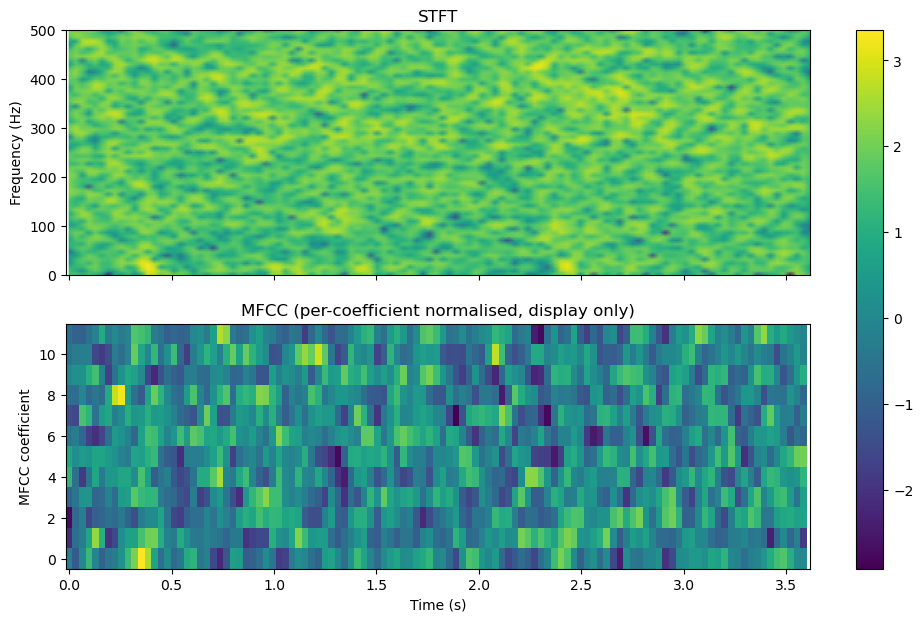

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from test_vectorized import read_audio_chunk
from stft import short_time_calc
from feature import make_mfcc_extractor

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
audio_file = DATA_22 / "20230422_171301.wav"

f_s, audio_array = read_audio_chunk(audio_file, 1, duration_hour=0.001)

# --- Standalone MFCC plot ---
extractor = make_mfcc_extractor()
m = extractor(audio_array, f_s)   # shape (n_mfcc, n_frames)
hop_samples = int(f_s * 0.128 * (1 - 0.75))
plot_mfcc(m, f_s, hop_samples)
plt.show()

# --- Side-by-side STFT vs MFCC comparison ---
fs_new = 1000
f, t, Zxx, _ = short_time_calc(audio_array, f_s, fs_new)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].pcolormesh(t, f, np.log(np.abs(Zxx) + 1e-16), shading="gouraud")
axes[0].set_title("STFT")
axes[0].set_ylabel("Frequency (Hz)")

img = plot_mfcc(m, f_s, hop_samples, ax=axes[1], normalise=True)
axes[1].set_title("MFCC (per-coefficient normalised, display only)")
axes[1].set_xlabel("Time (s)")

fig.colorbar(img, ax=axes)
plt.show()